# Notebook 03 — Base Model Benchmark
## FYP: Adaptive Explainable Ensemble for Pre-Launch Steam Game Reception Prediction
### Heshan Ratnaweera | IIT Sri Lanka | W2082289 | 2026

**Purpose:** Benchmark four classifiers (Logistic Regression, Random Forest, XGBoost, CatBoost)
on the full T4 feature set to establish a baseline and select the best classifier
for training specialist Models A–D in notebook 04.

**Inputs:** `data/processed/games_features_t4.csv`
**Outputs:** `outputs/results/benchmark_table.csv`
**Key results:** *(fill in after running)*

---
## Contents
1. Setup & Imports
2. Load Dataset
3. Train-Test Split
4. Define Classifiers
5. Cross-Validation Benchmark
6. Class Imbalance Strategy Comparison
7. Results Visualisation
8. Winner Selection
9. Save Benchmark Table


## 1. Setup & Imports

In [1]:
import sys
import warnings
import time
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ── Machine learning ───────────────────────────────────────────────────────────
from sklearn.linear_model    import LogisticRegression
from sklearn.ensemble        import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold, cross_validate, train_test_split
from sklearn.metrics         import (f1_score, roc_auc_score, precision_score,
                                     recall_score, confusion_matrix,
                                     ConfusionMatrixDisplay, classification_report)
from sklearn.preprocessing   import StandardScaler
from sklearn.pipeline        import Pipeline

from xgboost  import XGBClassifier
from catboost import CatBoostClassifier

# SMOTE for class imbalance handling
try:
    from imblearn.over_sampling import SMOTE
    from imblearn.pipeline      import Pipeline as ImbPipeline
    SMOTE_AVAILABLE = True
except ImportError:
    print('imbalanced-learn not installed — SMOTE comparison will be skipped')
    print('Install with: pip install imbalanced-learn')
    SMOTE_AVAILABLE = False

warnings.filterwarnings('ignore')
pd.set_option('display.float_format', '{:.4f}'.format)
sns.set_theme(style='darkgrid', palette='muted')

# ── Add project root to path ───────────────────────────────────────────────────
PROJECT_ROOT = Path.cwd().parent
sys.path.insert(0, str(PROJECT_ROOT))

from src.config import (
    FEATURES_T4_CSV, RESULTS_DIR, FIGURES_DIR,
    TARGET_COL, RANDOM_STATE, CV_FOLDS,
    TIER1_FEATURES, TIER2_FEATURES, TIER3_FEATURES
)

RESULTS_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

print('All imports OK')
print(f'Project root : {PROJECT_ROOT}')
print(f'Input CSV    : {FEATURES_T4_CSV}')


All imports OK
Project root : C:\Users\3214h\Documents\fyp-steam-reception
Input CSV    : C:\Users\3214h\Documents\fyp-steam-reception\data\processed\games_features_t4.csv


## 2. Load Dataset

Load `games_features_t4.csv` produced by notebook 02.
`short_description` is excluded from features here, it is used only in notebook 05 (SBERT).
`dlc_count` is also excluded from model features, it feeds `price_to_dlc_ratio` but is
not used as a standalone feature (r=0.005, not significant).


In [2]:
# ── Load the processed feature matrix ─────────────────────────────────────────
assert FEATURES_T4_CSV.exists(), f'File not found: {FEATURES_T4_CSV}. Run notebook 02 first.'

df = pd.read_csv(FEATURES_T4_CSV)
print(f'Loaded: {df.shape[0]:,} rows × {df.shape[1]} columns')
print(f'Class balance: {df[TARGET_COL].mean():.3f} positive ({df[TARGET_COL].mean()*100:.1f}%)')

# ── Define the full T4 feature set ────────────────────────────────────────────
# Exclude:
#   TARGET_COL        → this is what we are predicting (y)
#   short_description → text source for SBERT in notebook 05, not a numeric feature
#   dlc_count         → not used as standalone feature (only feeds price_to_dlc_ratio)
EXCLUDE_COLS = [TARGET_COL, 'short_description', 'dlc_count']

T4_FEATURES = [c for c in df.columns if c not in EXCLUDE_COLS]

print(f'\nT4 feature columns ({len(T4_FEATURES)} total):')
for i, col in enumerate(T4_FEATURES):
    print(f'  {i+1:>2}. {col}')


Loaded: 20,383 rows × 56 columns
Class balance: 0.718 positive (71.8%)

T4 feature columns (53 total):
   1. price
   2. required_age
   3. is_free
   4. price_to_dlc_ratio
   5. platform_coverage
   6. has_achievements
   7. has_website
   8. genre_concentration
   9. supported_languages_count
  10. screenshot_count
  11. movie_count
  12. genre_Indie
  13. genre_Adventure
  14. genre_Action
  15. genre_Casual
  16. genre_Simulation
  17. genre_RPG
  18. genre_Strategy
  19. genre_Free_To_Play
  20. genre_Early_Access
  21. genre_Massively_Multiplayer
  22. tag_Singleplayer
  23. tag_Indie
  24. tag_Adventure
  25. tag_Action
  26. tag_Casual
  27. tag_2D
  28. tag_Simulation
  29. tag_RPG
  30. tag_Atmospheric
  31. tag_Story_Rich
  32. tag_Strategy
  33. tag_Multiplayer
  34. tag_Puzzle
  35. tag_Exploration
  36. tag_First_Person
  37. tag_Anime
  38. tag_Funny
  39. tag_3D
  40. tag_Cute
  41. tag_Fantasy
  42. cat_Single_player
  43. cat_Multi_player
  44. cat_Co_op
  45. cat_Ste

## 3. Train-Test Split

80% train / 20% test, stratified by label to preserve the 71.8% / 28.2% class ratio.
The test set is held out completely — it is only used in section 8 for final evaluation
of the winning model. Cross-validation in sections 5 and 6 uses only the train set.

`RANDOM_STATE = 42` ensures reproducibility across all runs.


In [3]:
# ── Prepare feature matrix X and label vector y ───────────────────────────────
X = df[T4_FEATURES].values   # numpy array — faster for sklearn
y = df[TARGET_COL].values

print(f'X shape: {X.shape}')
print(f'y shape: {y.shape}')
print(f'Positive class (label=1): {y.sum():,} ({y.mean()*100:.1f}%)')
print(f'Negative class (label=0): {(1-y).sum():,} ({(1-y).mean()*100:.1f}%)')

# ── Stratified train-test split ────────────────────────────────────────────────
# stratify=y ensures both splits have the same class ratio as the full dataset
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y      # preserves 71.8% / 28.2% ratio in both splits
)

print(f'\nTrain set : {X_train.shape[0]:,} games  '
      f'(positive: {y_train.mean()*100:.1f}%)')
print(f'Test set  : {X_test.shape[0]:,} games  '
      f'(positive: {y_test.mean()*100:.1f}%)')
print(f'\nTest set is held out until section 8 — not used during cross-validation')


X shape: (20383, 53)
y shape: (20383,)
Positive class (label=1): 14,631 (71.8%)
Negative class (label=0): 5,752 (28.2%)

Train set : 16,306 games  (positive: 71.8%)
Test set  : 4,077 games  (positive: 71.8%)

Test set is held out until section 8 — not used during cross-validation


## 4. Define Classifiers

Four classifiers are benchmarked:

**Logistic Regression** — linear baseline. Requires feature scaling (StandardScaler).
Tells us whether the problem has a linear solution.

**Random Forest** — ensemble of decision trees. No scaling needed. Good baseline
for tree-based methods.

**XGBoost** — gradient boosting. Generally strong on tabular data. Fast training.

**CatBoost** — gradient boosting designed for categorical features. Handles class
imbalance well via `scale_pos_weight`. Often the strongest performer on mixed
tabular datasets.

The winner from this benchmark becomes the classifier for Models A–D in notebook 04.


In [4]:
# ── Class imbalance weight ────────────────────────────────────────────────────
# Goal: treat both classes equally → PRIMARY METRIC is macro F1.
# All four classifiers must use equivalent imbalance handling for a fair comparison.
# sklearn classifiers: class_weight='balanced'
# XGBoost / CatBoost: scale_pos_weight = neg_count / pos_count (same effect)
neg_count = (y_train == 0).sum()
pos_count = (y_train == 1).sum()
scale_pos_weight = neg_count / pos_count

print(f'Training set class distribution:')
print(f'  Not Well Received (label=0): {neg_count:,}  ({neg_count/len(y_train)*100:.1f}%)')
print(f'  Well Received     (label=1): {pos_count:,}  ({pos_count/len(y_train)*100:.1f}%)')
print(f'  scale_pos_weight           : {scale_pos_weight:.4f}')
print(f'\nAll classifiers configured with equivalent class imbalance handling.')

CLASSIFIERS = {

    'Logistic Regression': Pipeline([
        ('scaler', StandardScaler()),
        ('clf', LogisticRegression(
            class_weight='balanced',
            max_iter=1000,
            random_state=RANDOM_STATE,
            n_jobs=-1
        ))
    ]),

    'Random Forest': RandomForestClassifier(
        n_estimators=300,
        class_weight='balanced',   # upweights minority class proportionally
        max_depth=None,
        min_samples_leaf=2,
        random_state=RANDOM_STATE,
        n_jobs=-1
    ),

    'XGBoost': XGBClassifier(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=6,
        scale_pos_weight=scale_pos_weight,  # equivalent to class_weight='balanced'
        eval_metric='logloss',
        use_label_encoder=False,
        random_state=RANDOM_STATE,
        n_jobs=-1,
        verbosity=0
    ),

    'CatBoost': CatBoostClassifier(
        iterations=300,
        learning_rate=0.05,
        depth=6,
        scale_pos_weight=scale_pos_weight,  # equivalent to class_weight='balanced'
        random_seed=RANDOM_STATE,
        verbose=0
    ),
}

print(f'\n{len(CLASSIFIERS)} classifiers defined:')
for name in CLASSIFIERS:
    print(f'  - {name}')


Training set class distribution:
  Not Well Received (label=0): 4,601  (28.2%)
  Well Received     (label=1): 11,705  (71.8%)
  scale_pos_weight           : 0.3931

All classifiers configured with equivalent class imbalance handling.

4 classifiers defined:
  - Logistic Regression
  - Random Forest
  - XGBoost
  - CatBoost


## 5. Cross-Validation Benchmark

5-fold stratified cross-validation on the **training set only**.
The test set remains untouched.

Metrics recorded for each fold:
- **F1 (minority class)** — primary metric. Balances precision and recall for label=0
- **AUC-ROC** — overall discriminative ability across all thresholds
- **Precision** — of games predicted "not well received", how many actually are?
- **Recall** — of games that are "not well received", how many did we catch?

F1 on the minority class is primary because accuracy would be misleading —
a model that always predicts "Well Received" would achieve 71.8% accuracy
without learning anything useful.


In [5]:
from sklearn.metrics import make_scorer

# Scorers for each class specifically
# pos_label=0 → F1 for the minority class (Not Well Received)
# pos_label=1 → F1 for the majority class (Well Received)
f1_minority_scorer = make_scorer(f1_score, pos_label=0)
f1_majority_scorer = make_scorer(f1_score, pos_label=1)

# PRIMARY METRIC: macro F1 = (F1_minority + F1_majority) / 2
# Equal weight to both classes — aligns with project goal of helping developers
# identify both successes and games at risk of poor reception.
cv = StratifiedKFold(n_splits=CV_FOLDS, shuffle=True, random_state=RANDOM_STATE)
cv_results = {}

print(f'Running {CV_FOLDS}-fold stratified CV on training set ({X_train.shape[0]:,} games)...')
print(f'PRIMARY METRIC: Macro F1 (equal weight to both classes)')
print()

for name, clf in CLASSIFIERS.items():
    print(f'Training {name}...', end=' ', flush=True)
    start = time.time()

    scores = cross_validate(
        clf, X_train, y_train,
        cv=cv,
        scoring={
            'f1_macro':    'f1_macro',         # PRIMARY — equal weight both classes
            'f1_minority': f1_minority_scorer,  # F1 for Not Well Received (label=0)
            'f1_majority': f1_majority_scorer,  # F1 for Well Received (label=1)
            'roc_auc':     'roc_auc',
            'precision':   'precision_macro',
            'recall':      'recall_macro',
        },
        n_jobs=1,
        return_train_score=False
    )

    elapsed = time.time() - start

    cv_results[name] = {
        'f1_macro_mean':    scores['test_f1_macro'].mean(),
        'f1_macro_std':     scores['test_f1_macro'].std(),
        'f1_minority_mean': scores['test_f1_minority'].mean(),
        'f1_minority_std':  scores['test_f1_minority'].std(),
        'f1_majority_mean': scores['test_f1_majority'].mean(),
        'f1_majority_std':  scores['test_f1_majority'].std(),
        'auc_mean':         scores['test_roc_auc'].mean(),
        'auc_std':          scores['test_roc_auc'].std(),
        'precision_mean':   scores['test_precision'].mean(),
        'recall_mean':      scores['test_recall'].mean(),
        'time_sec':         elapsed,
        'fold_macro_f1s':   scores['test_f1_macro'].tolist(),
        'fold_minor_f1s':   scores['test_f1_minority'].tolist(),
    }

    print(f'done in {elapsed:.1f}s  |  '
          f'Macro F1={scores["test_f1_macro"].mean():.4f} ± {scores["test_f1_macro"].std():.4f}  |  '
          f'Minority F1={scores["test_f1_minority"].mean():.4f}  |  '
          f'AUC={scores["test_roc_auc"].mean():.4f}')

print()
results_df = pd.DataFrame({
    name: {
        'Macro F1 (mean)':    f'{r["f1_macro_mean"]:.4f}',
        'Macro F1 (± std)':   f'{r["f1_macro_std"]:.4f}',
        'Minority F1 (mean)': f'{r["f1_minority_mean"]:.4f}',
        'Majority F1 (mean)': f'{r["f1_majority_mean"]:.4f}',
        'AUC-ROC (mean)':     f'{r["auc_mean"]:.4f}',
        'AUC-ROC (± std)':    f'{r["auc_std"]:.4f}',
        'Macro Precision':    f'{r["precision_mean"]:.4f}',
        'Macro Recall':       f'{r["recall_mean"]:.4f}',
        'Train time (s)':     f'{r["time_sec"]:.1f}',
    }
    for name, r in cv_results.items()
}).T

print('=== 5-FOLD CV RESULTS — PRIMARY METRIC: MACRO F1 ===')
print(results_df.to_string())
print()
print('Minority F1 = F1 for Not Well Received (label=0) — detecting games at risk')
print('Majority F1 = F1 for Well Received     (label=1)')


Running 5-fold stratified CV on training set (16,306 games)...
PRIMARY METRIC: Macro F1 (equal weight to both classes)

Training Logistic Regression... done in 0.3s  |  Macro F1=0.6311 ± 0.0040  |  Minority F1=0.5218  |  AUC=0.7158
Training Random Forest... done in 6.1s  |  Macro F1=0.6677 ± 0.0086  |  Minority F1=0.5243  |  AUC=0.7444
Training XGBoost... done in 2.7s  |  Macro F1=0.6591 ± 0.0072  |  Minority F1=0.5390  |  AUC=0.7379
Training CatBoost... done in 9.5s  |  Macro F1=0.6580 ± 0.0019  |  Minority F1=0.5438  |  AUC=0.7443

=== 5-FOLD CV RESULTS — PRIMARY METRIC: MACRO F1 ===
                    Macro F1 (mean) Macro F1 (± std) Minority F1 (mean) Majority F1 (mean) AUC-ROC (mean) AUC-ROC (± std) Macro Precision Macro Recall Train time (s)
Logistic Regression          0.6311           0.0040             0.5218             0.7404         0.7158          0.0079          0.6326       0.6596            0.3
Random Forest                0.6677           0.0086             0.5243    

## 6. Class Imbalance Strategy Comparison

Three strategies for handling the 71.8% / 28.2% class imbalance:

**No resampling** — train on the raw imbalanced data, rely on class_weight parameter

**class_weight='balanced'** — already used in section 5; sklearn automatically
adjusts sample weights so the minority class has equal total weight

**SMOTE** — Synthetic Minority Over-sampling Technique. Creates synthetic examples
of the minority class by interpolating between existing minority samples.
Applied only to the training fold, never to the validation fold (no leakage).

We test these three strategies on the best classifier from section 5.


In [6]:
# ── Select best classifier by MACRO F1 ────────────────────────────────────────
best_name = max(cv_results, key=lambda k: cv_results[k]['f1_macro_mean'])
print(f'Best classifier by Macro F1: {best_name}')
print(f'  Macro F1    = {cv_results[best_name]["f1_macro_mean"]:.4f} ± {cv_results[best_name]["f1_macro_std"]:.4f}')
print(f'  Minority F1 = {cv_results[best_name]["f1_minority_mean"]:.4f}')
print(f'  Majority F1 = {cv_results[best_name]["f1_majority_mean"]:.4f}')
print()

# ── Compare three imbalance strategies — all measured by MACRO F1 ─────────────
imbalance_results = {}

# Strategy 1: class_weight (already in section 5)
print('Strategy 1: class_weight="balanced" / scale_pos_weight (already in section 5)...')
imbalance_results['class_weight'] = {
    'f1_macro_mean':    cv_results[best_name]['f1_macro_mean'],
    'f1_macro_std':     cv_results[best_name]['f1_macro_std'],
    'f1_minority_mean': cv_results[best_name]['f1_minority_mean'],
    'auc_mean':         cv_results[best_name]['auc_mean'],
}
print(f'  Macro F1={imbalance_results["class_weight"]["f1_macro_mean"]:.4f}  '
      f'Minority F1={imbalance_results["class_weight"]["f1_minority_mean"]:.4f}')

# Strategy 2: No class weighting
print('Strategy 2: No class weighting...')
if best_name == 'CatBoost':
    clf_nw = CatBoostClassifier(iterations=300, learning_rate=0.05, depth=6,
                                 random_seed=RANDOM_STATE, verbose=0)
elif best_name == 'XGBoost':
    clf_nw = XGBClassifier(n_estimators=300, learning_rate=0.05, max_depth=6,
                            eval_metric='logloss', use_label_encoder=False,
                            random_state=RANDOM_STATE, n_jobs=-1, verbosity=0)
elif best_name == 'Random Forest':
    clf_nw = RandomForestClassifier(n_estimators=300, max_depth=None,
                                    min_samples_leaf=2, random_state=RANDOM_STATE, n_jobs=-1)
else:
    clf_nw = Pipeline([('scaler', StandardScaler()),
                       ('clf', LogisticRegression(max_iter=1000,
                                                  random_state=RANDOM_STATE, n_jobs=-1))])

s_nw = cross_validate(clf_nw, X_train, y_train, cv=cv,
                      scoring={'f1_macro': 'f1_macro',
                               'f1_minority': f1_minority_scorer,
                               'roc_auc': 'roc_auc'}, n_jobs=1)
imbalance_results['no_weighting'] = {
    'f1_macro_mean':    s_nw['test_f1_macro'].mean(),
    'f1_macro_std':     s_nw['test_f1_macro'].std(),
    'f1_minority_mean': s_nw['test_f1_minority'].mean(),
    'auc_mean':         s_nw['test_roc_auc'].mean(),
}
print(f'  Macro F1={imbalance_results["no_weighting"]["f1_macro_mean"]:.4f}  '
      f'Minority F1={imbalance_results["no_weighting"]["f1_minority_mean"]:.4f}')

# Strategy 3: SMOTE
if SMOTE_AVAILABLE:
    print('Strategy 3: SMOTE...')
    smote_clf = ImbPipeline([('smote', SMOTE(random_state=RANDOM_STATE)),
                              ('clf', CLASSIFIERS[best_name])])
    s_sm = cross_validate(smote_clf, X_train, y_train, cv=cv,
                          scoring={'f1_macro': 'f1_macro',
                                   'f1_minority': f1_minority_scorer,
                                   'roc_auc': 'roc_auc'}, n_jobs=1)
    imbalance_results['SMOTE'] = {
        'f1_macro_mean':    s_sm['test_f1_macro'].mean(),
        'f1_macro_std':     s_sm['test_f1_macro'].std(),
        'f1_minority_mean': s_sm['test_f1_minority'].mean(),
        'auc_mean':         s_sm['test_roc_auc'].mean(),
    }
    print(f'  Macro F1={imbalance_results["SMOTE"]["f1_macro_mean"]:.4f}  '
          f'Minority F1={imbalance_results["SMOTE"]["f1_minority_mean"]:.4f}')
else:
    print('Strategy 3: SMOTE skipped — install imbalanced-learn to enable')

print()
print(f'=== IMBALANCE STRATEGY COMPARISON ({best_name}) — ranked by Macro F1 ===')
print(f'  {"Strategy":<20} {"Macro F1":>10} {"Minority F1":>12} {"AUC":>8}')
print('  ' + '-' * 54)
for strat, r in sorted(imbalance_results.items(),
                        key=lambda x: x[1]['f1_macro_mean'], reverse=True):
    print(f'  {strat:<20} {r["f1_macro_mean"]:>10.4f} {r["f1_minority_mean"]:>12.4f} {r["auc_mean"]:>8.4f}')

best_strategy = max(imbalance_results, key=lambda k: imbalance_results[k]['f1_macro_mean'])
print(f'\n  Best strategy (by Macro F1): {best_strategy}')


Best classifier by Macro F1: Random Forest
  Macro F1    = 0.6677 ± 0.0086
  Minority F1 = 0.5243
  Majority F1 = 0.8111

Strategy 1: class_weight="balanced" / scale_pos_weight (already in section 5)...
  Macro F1=0.6677  Minority F1=0.5243
Strategy 2: No class weighting...
  Macro F1=0.6043  Minority F1=0.3617
Strategy 3: SMOTE...
  Macro F1=0.6205  Minority F1=0.3973

=== IMBALANCE STRATEGY COMPARISON (Random Forest) — ranked by Macro F1 ===
  Strategy               Macro F1  Minority F1      AUC
  ------------------------------------------------------
  class_weight             0.6677       0.5243   0.7444
  SMOTE                    0.6205       0.3973   0.7419
  no_weighting             0.6043       0.3617   0.7422

  Best strategy (by Macro F1): class_weight


## 7. Results Visualisation

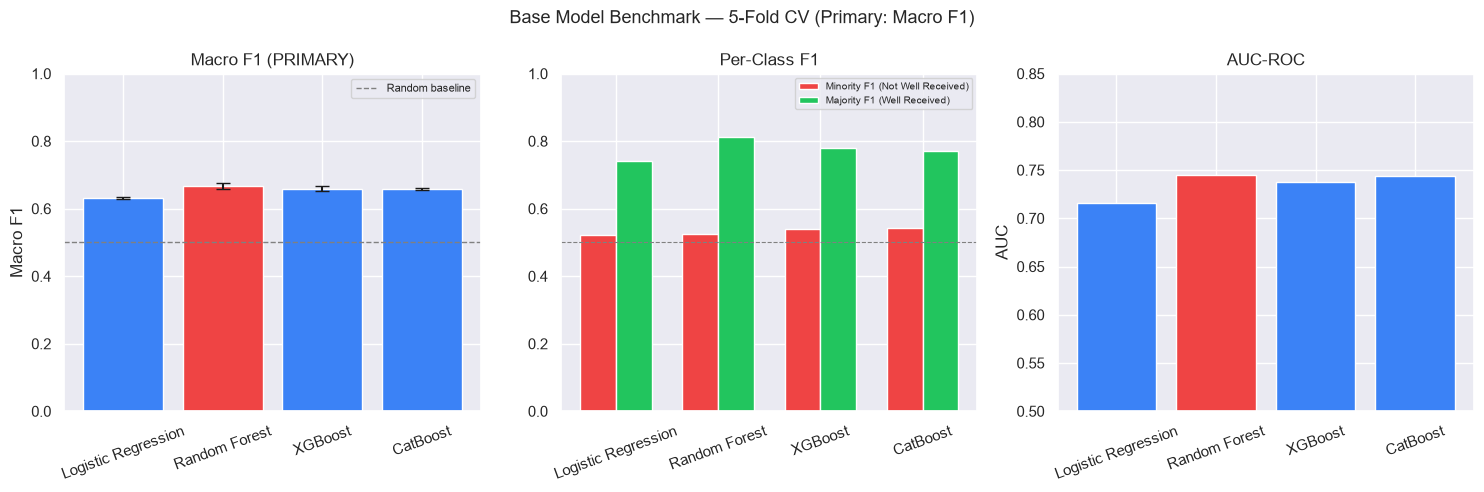

Saved: 03_benchmark_comparison.png


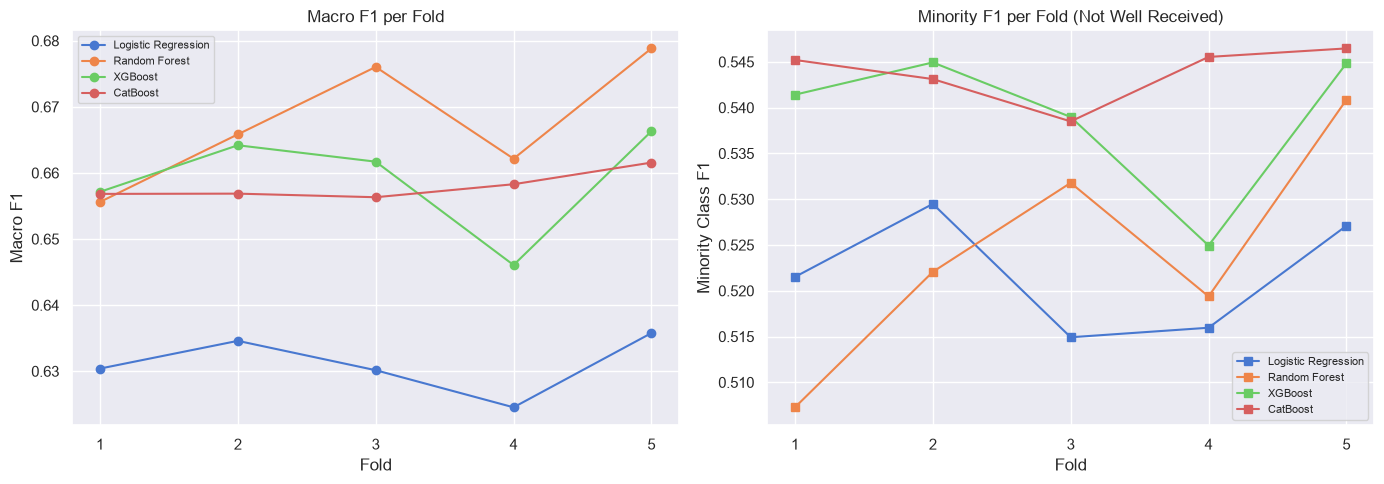

Saved: 03_fold_stability.png


In [7]:
names        = list(cv_results.keys())
macro_f1s    = [cv_results[n]['f1_macro_mean']   for n in names]
macro_f1_std = [cv_results[n]['f1_macro_std']    for n in names]
minor_f1s    = [cv_results[n]['f1_minority_mean'] for n in names]
major_f1s    = [cv_results[n]['f1_majority_mean'] for n in names]
aucs         = [cv_results[n]['auc_mean']         for n in names]
colors       = ['#ef4444' if n == best_name else '#3b82f6' for n in names]

# ── Chart 1: Macro F1 + per-class F1 + AUC ───────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('Base Model Benchmark — 5-Fold CV (Primary: Macro F1)', fontsize=13)

# Macro F1 with error bars
axes[0].bar(names, macro_f1s, yerr=macro_f1_std, color=colors, capsize=5, edgecolor='white')
axes[0].set_title('Macro F1 (PRIMARY)')
axes[0].set_ylabel('Macro F1')
axes[0].set_ylim(0, 1)
axes[0].tick_params(axis='x', rotation=20)
axes[0].axhline(0.5, color='gray', linestyle='--', linewidth=1, label='Random baseline')
axes[0].legend(fontsize=8)

# Per-class F1 side by side
x = np.arange(len(names))
w = 0.35
axes[1].bar(x - w/2, minor_f1s, w, label='Minority F1 (Not Well Received)',
            color='#ef4444', edgecolor='white')
axes[1].bar(x + w/2, major_f1s, w, label='Majority F1 (Well Received)',
            color='#22c55e', edgecolor='white')
axes[1].set_title('Per-Class F1')
axes[1].set_xticks(x)
axes[1].set_xticklabels(names, rotation=20)
axes[1].set_ylim(0, 1)
axes[1].legend(fontsize=7)
axes[1].axhline(0.5, color='gray', linestyle='--', linewidth=0.8)

# AUC-ROC
axes[2].bar(names, aucs, color=colors, edgecolor='white')
axes[2].set_title('AUC-ROC')
axes[2].set_ylabel('AUC')
axes[2].set_ylim(0.5, 0.85)
axes[2].tick_params(axis='x', rotation=20)

plt.tight_layout()
plt.savefig(PROJECT_ROOT / 'outputs' / 'figures' / '03_benchmark_comparison.png',
            dpi=150, bbox_inches='tight')
plt.show()
print('Saved: 03_benchmark_comparison.png')

# ── Chart 2: Per-fold stability ───────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for name, r in cv_results.items():
    folds = range(1, CV_FOLDS + 1)
    axes[0].plot(folds, r['fold_macro_f1s'], marker='o', label=name, linewidth=1.5)
axes[0].set_xlabel('Fold')
axes[0].set_ylabel('Macro F1')
axes[0].set_title('Macro F1 per Fold')
axes[0].legend(fontsize=8)
axes[0].set_xticks(range(1, CV_FOLDS + 1))

for name, r in cv_results.items():
    axes[1].plot(range(1, CV_FOLDS + 1), r['fold_minor_f1s'],
                 marker='s', label=name, linewidth=1.5)
axes[1].set_xlabel('Fold')
axes[1].set_ylabel('Minority Class F1')
axes[1].set_title('Minority F1 per Fold (Not Well Received)')
axes[1].legend(fontsize=8)
axes[1].set_xticks(range(1, CV_FOLDS + 1))

plt.tight_layout()
plt.savefig(PROJECT_ROOT / 'outputs' / 'figures' / '03_fold_stability.png',
            dpi=150, bbox_inches='tight')
plt.show()
print('Saved: 03_fold_stability.png')


## 8. Winner Selection & Final Evaluation on Test Set

The best classifier is retrained on the **full training set** and evaluated
on the **held-out test set** for a final unbiased performance estimate.

This is the only time the test set is used in this notebook.


Selected classifier : Random Forest
Imbalance strategy  : class_weight
CV Macro F1         : 0.6677 ± 0.0086
CV Minority F1      : 0.5243

Fitting Random Forest on full training set (16,306 games)...
Done.

Tuning decision threshold to maximise Macro F1...
  Default  threshold (0.50): Macro F1 = 0.6723  Minority F1 = 0.5321
  Optimal threshold (0.50): Macro F1 = 0.6723  Minority F1 = 0.5321


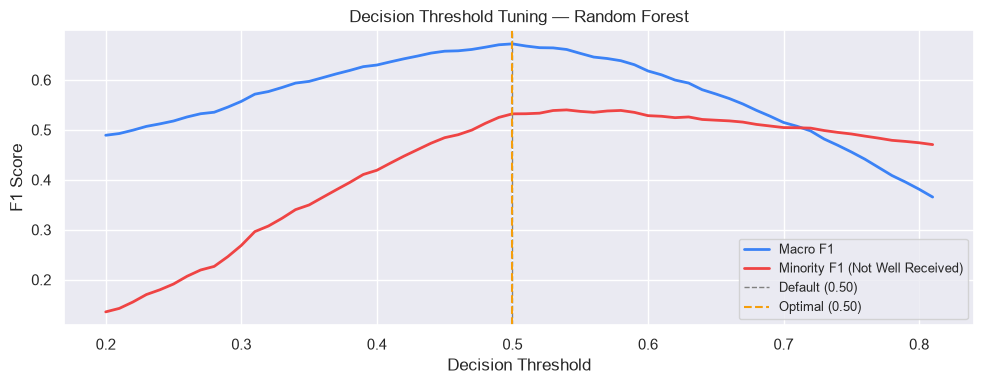

Saved: 03_threshold_tuning.png

=== TEST SET RESULTS — Random Forest ===
  Metric                       Default (0.50) Optimal (0.50)
  ------------------------------------------------------------
  Macro F1 (PRIMARY)                   0.6723         0.6723
  Minority F1 (Not Well Rec.)          0.5321         0.5321
  AUC-ROC                              0.7360         0.7360

Classification report (optimal threshold = 0.50):
                   precision    recall  f1-score   support

Not Well Received       0.52      0.54      0.53      1151
    Well Received       0.82      0.81      0.81      2926

         accuracy                           0.73      4077
        macro avg       0.67      0.67      0.67      4077
     weighted avg       0.73      0.73      0.73      4077



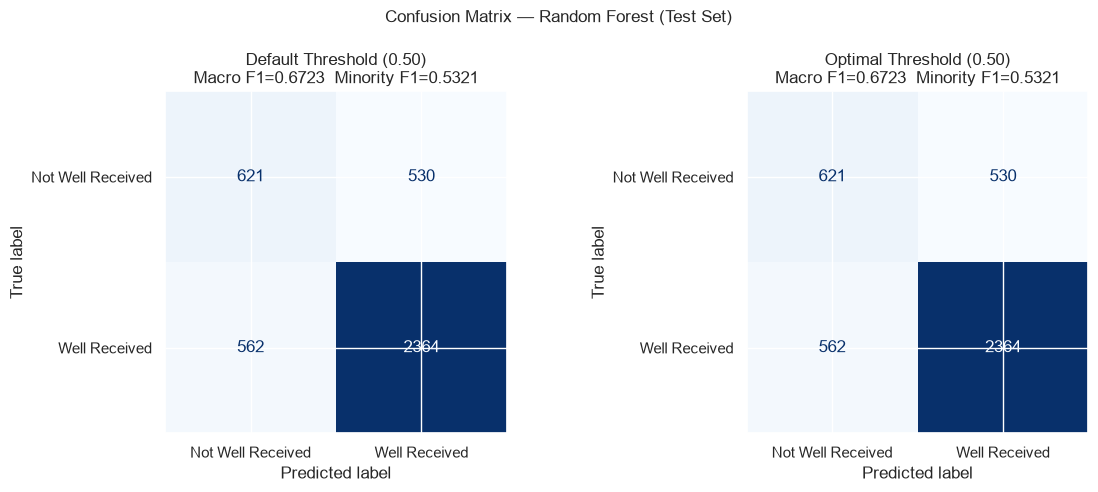

Saved: 03_confusion_matrix.png


In [8]:
WINNER_NAME     = best_name
WINNER_STRATEGY = best_strategy
print(f'Selected classifier : {WINNER_NAME}')
print(f'Imbalance strategy  : {WINNER_STRATEGY}')
print(f'CV Macro F1         : {cv_results[WINNER_NAME]["f1_macro_mean"]:.4f} ± '
      f'{cv_results[WINNER_NAME]["f1_macro_std"]:.4f}')
print(f'CV Minority F1      : {cv_results[WINNER_NAME]["f1_minority_mean"]:.4f}')
print()

# ── Build final model with the winning imbalance strategy ─────────────────────
if WINNER_STRATEGY == 'no_weighting':
    if WINNER_NAME == 'CatBoost':
        final_clf = CatBoostClassifier(iterations=300, learning_rate=0.05,
                                        depth=6, random_seed=RANDOM_STATE, verbose=0)
    elif WINNER_NAME == 'XGBoost':
        final_clf = XGBClassifier(n_estimators=300, learning_rate=0.05, max_depth=6,
                                   eval_metric='logloss', use_label_encoder=False,
                                   random_state=RANDOM_STATE, n_jobs=-1, verbosity=0)
    elif WINNER_NAME == 'Random Forest':
        final_clf = RandomForestClassifier(n_estimators=300, max_depth=None,
                                            min_samples_leaf=2, random_state=RANDOM_STATE, n_jobs=-1)
    else:
        final_clf = Pipeline([('scaler', StandardScaler()),
                               ('clf', LogisticRegression(max_iter=1000,
                                                          random_state=RANDOM_STATE, n_jobs=-1))])
elif WINNER_STRATEGY == 'SMOTE' and SMOTE_AVAILABLE:
    final_clf = ImbPipeline([('smote', SMOTE(random_state=RANDOM_STATE)),
                              ('clf', CLASSIFIERS[WINNER_NAME])])
else:
    final_clf = CLASSIFIERS[WINNER_NAME]

# ── Retrain on full training set ───────────────────────────────────────────────
print(f'Fitting {WINNER_NAME} on full training set ({X_train.shape[0]:,} games)...')
final_clf.fit(X_train, y_train)
print('Done.')

# ── Decision threshold tuning ──────────────────────────────────────────────────
# Default threshold is 0.5: predict label=1 if predict_proba >= 0.5.
# A lower threshold makes the model more likely to predict "Not Well Received",
# improving minority class recall. We search for the threshold that maximises macro F1.
print()
print('Tuning decision threshold to maximise Macro F1...')
y_prob = final_clf.predict_proba(X_test)[:, 1]

thresholds   = np.arange(0.20, 0.81, 0.01)
macro_f1s_t  = []
minor_f1s_t  = []

for t in thresholds:
    y_pred_t = (y_prob >= t).astype(int)
    macro_f1s_t.append(f1_score(y_test, y_pred_t, average='macro', zero_division=0))
    minor_f1s_t.append(f1_score(y_test, y_pred_t, pos_label=0, zero_division=0))

best_t_idx     = int(np.argmax(macro_f1s_t))
BEST_THRESHOLD = float(thresholds[best_t_idx])
default_idx    = int(np.argmin(np.abs(thresholds - 0.50)))

print(f'  Default  threshold (0.50): Macro F1 = {macro_f1s_t[default_idx]:.4f}  '
      f'Minority F1 = {minor_f1s_t[default_idx]:.4f}')
print(f'  Optimal threshold ({BEST_THRESHOLD:.2f}): Macro F1 = {macro_f1s_t[best_t_idx]:.4f}  '
      f'Minority F1 = {minor_f1s_t[best_t_idx]:.4f}')

# Threshold curve plot
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(thresholds, macro_f1s_t, label='Macro F1',        color='#3b82f6', linewidth=2)
ax.plot(thresholds, minor_f1s_t, label='Minority F1 (Not Well Received)',
        color='#ef4444', linewidth=2)
ax.axvline(0.50, color='gray',    linestyle='--', linewidth=1, label='Default (0.50)')
ax.axvline(BEST_THRESHOLD, color='#f59e0b', linestyle='--', linewidth=1.5,
           label=f'Optimal ({BEST_THRESHOLD:.2f})')
ax.set_xlabel('Decision Threshold')
ax.set_ylabel('F1 Score')
ax.set_title(f'Decision Threshold Tuning — {WINNER_NAME}')
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig(PROJECT_ROOT / 'outputs' / 'figures' / '03_threshold_tuning.png',
            dpi=150, bbox_inches='tight')
plt.show()
print('Saved: 03_threshold_tuning.png')

# ── Final test evaluation at both thresholds ───────────────────────────────────
y_pred_default = (y_prob >= 0.50).astype(int)
y_pred_optimal = (y_prob >= BEST_THRESHOLD).astype(int)

test_macro_default  = f1_score(y_test, y_pred_default, average='macro')
test_macro_optimal  = f1_score(y_test, y_pred_optimal, average='macro')
test_minor_default  = f1_score(y_test, y_pred_default, pos_label=0)
test_minor_optimal  = f1_score(y_test, y_pred_optimal, pos_label=0)
test_auc            = roc_auc_score(y_test, y_prob)

print()
print(f'=== TEST SET RESULTS — {WINNER_NAME} ===')
print(f'  {"Metric":<28} {"Default (0.50)":>14} {"Optimal ({:.2f})".format(BEST_THRESHOLD):>14}')
print('  ' + '-' * 60)
print(f'  {"Macro F1 (PRIMARY)":<28} {test_macro_default:>14.4f} {test_macro_optimal:>14.4f}')
print(f'  {"Minority F1 (Not Well Rec.)":<28} {test_minor_default:>14.4f} {test_minor_optimal:>14.4f}')
print(f'  {"AUC-ROC":<28} {test_auc:>14.4f} {test_auc:>14.4f}')
print()
print(f'Classification report (optimal threshold = {BEST_THRESHOLD:.2f}):')
print(classification_report(y_test, y_pred_optimal,
                             target_names=['Not Well Received', 'Well Received']))

# ── Side-by-side confusion matrices ───────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, (y_pred, title) in zip(axes, [
    (y_pred_default, 'Default Threshold (0.50)'),
    (y_pred_optimal, f'Optimal Threshold ({BEST_THRESHOLD:.2f})')
]):
    cm   = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(cm, display_labels=['Not Well Received', 'Well Received'])
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    mf1 = f1_score(y_test, y_pred, average='macro')
    mnf = f1_score(y_test, y_pred, pos_label=0)
    ax.set_title(f'{title}\nMacro F1={mf1:.4f}  Minority F1={mnf:.4f}')

plt.suptitle(f'Confusion Matrix — {WINNER_NAME} (Test Set)', fontsize=12)
plt.tight_layout()
plt.savefig(PROJECT_ROOT / 'outputs' / 'figures' / '03_confusion_matrix.png',
            dpi=150, bbox_inches='tight')
plt.show()
print('Saved: 03_confusion_matrix.png')


## 9. Save Benchmark Table

In [9]:
rows = []
for name, r in cv_results.items():
    is_win = (name == WINNER_NAME)
    rows.append({
        'classifier':             name,
        'cv_macro_f1_mean':       round(r['f1_macro_mean'], 4),
        'cv_macro_f1_std':        round(r['f1_macro_std'], 4),
        'cv_minority_f1_mean':    round(r['f1_minority_mean'], 4),
        'cv_majority_f1_mean':    round(r['f1_majority_mean'], 4),
        'cv_auc_mean':            round(r['auc_mean'], 4),
        'cv_auc_std':             round(r['auc_std'], 4),
        'train_time_sec':         round(r['time_sec'], 1),
        'is_winner':              is_win,
        'imbalance_strategy':     WINNER_STRATEGY if is_win else 'class_weight',
        'test_macro_f1_default':  round(test_macro_default, 4) if is_win else None,
        'test_macro_f1_optimal':  round(test_macro_optimal, 4) if is_win else None,
        'test_minority_f1':       round(test_minor_optimal, 4) if is_win else None,
        'test_auc':               round(test_auc, 4)           if is_win else None,
        'optimal_threshold':      round(BEST_THRESHOLD, 2)     if is_win else None,
    })

benchmark_df = pd.DataFrame(rows)
benchmark_df.to_csv(RESULTS_DIR / 'benchmark_table.csv', index=False)
print(f'Saved: {RESULTS_DIR / "benchmark_table.csv"}')
print()
print('=== BENCHMARK TABLE (sorted by Macro F1) ===')
print(benchmark_df.sort_values('cv_macro_f1_mean', ascending=False).to_string(index=False))


Saved: C:\Users\3214h\Documents\fyp-steam-reception\outputs\results\benchmark_table.csv

=== BENCHMARK TABLE (sorted by Macro F1) ===
         classifier  cv_macro_f1_mean  cv_macro_f1_std  cv_minority_f1_mean  cv_majority_f1_mean  cv_auc_mean  cv_auc_std  train_time_sec  is_winner imbalance_strategy  test_macro_f1_default  test_macro_f1_optimal  test_minority_f1  test_auc  optimal_threshold
      Random Forest            0.6677           0.0086               0.5243               0.8111       0.7444      0.0054          6.1000       True       class_weight                 0.6723                 0.6723            0.5321    0.7360             0.5000
            XGBoost            0.6591           0.0072               0.5390               0.7791       0.7379      0.0069          2.7000      False       class_weight                    NaN                    NaN               NaN       NaN                NaN
           CatBoost            0.6580           0.0019               0.5438        

## 10. Summary

In [10]:
print('=' * 65)
print('NOTEBOOK 03 — BASE MODEL BENCHMARK SUMMARY')
print('=' * 65)

print(f'\nDATASET')
print(f'  Total games    : {len(df):,}')
print(f'  Features (T4)  : {len(T4_FEATURES)}')
print(f'  Train set      : {X_train.shape[0]:,} games')
print(f'  Test set       : {X_test.shape[0]:,} games')
print(f'  CV strategy    : {CV_FOLDS}-fold stratified')
print(f'  Primary metric : Macro F1 (equal weight to both classes)')

print(f'\nCLASSIFIER RANKING (by CV Macro F1):')
ranked = sorted(cv_results.items(), key=lambda x: x[1]['f1_macro_mean'], reverse=True)
for rank, (name, r) in enumerate(ranked, 1):
    marker = ' ← WINNER' if name == WINNER_NAME else ''
    print(f'  {rank}. {name:<25} '
          f'Macro F1={r["f1_macro_mean"]:.4f} ± {r["f1_macro_std"]:.4f}  '
          f'Minority F1={r["f1_minority_mean"]:.4f}{marker}')

print(f'\nWINNER: {WINNER_NAME}')
print(f'  Imbalance strategy      : {WINNER_STRATEGY}')
print(f'  CV Macro F1             : {cv_results[WINNER_NAME]["f1_macro_mean"]:.4f} ± '
      f'{cv_results[WINNER_NAME]["f1_macro_std"]:.4f}')
print(f'  CV Minority F1          : {cv_results[WINNER_NAME]["f1_minority_mean"]:.4f}')
print(f'  Test Macro F1 (default) : {test_macro_default:.4f}  (threshold=0.50)')
print(f'  Test Macro F1 (optimal) : {test_macro_optimal:.4f}  (threshold={BEST_THRESHOLD:.2f})')
print(f'  Test Minority F1        : {test_minor_optimal:.4f}')
print(f'  Test AUC-ROC            : {test_auc:.4f}')
print(f'  Optimal threshold       : {BEST_THRESHOLD:.2f}')

print(f'\nNEXT STEP: Notebook 04 — Specialist Models + Router')
print(f'  Classifier      : {WINNER_NAME}')
print(f'  Imbalance       : {WINNER_STRATEGY}')
print(f'  Primary metric  : Macro F1')
print(f'  Threshold       : {BEST_THRESHOLD:.2f}  (use for all specialist models)')
print(f'  Train Models A (T1), B (T2), C (T3), D (T4)')
print(f'  Implement confidence-based router')
print('=' * 65)


NOTEBOOK 03 — BASE MODEL BENCHMARK SUMMARY

DATASET
  Total games    : 20,383
  Features (T4)  : 53
  Train set      : 16,306 games
  Test set       : 4,077 games
  CV strategy    : 5-fold stratified
  Primary metric : Macro F1 (equal weight to both classes)

CLASSIFIER RANKING (by CV Macro F1):
  1. Random Forest             Macro F1=0.6677 ± 0.0086  Minority F1=0.5243 ← WINNER
  2. XGBoost                   Macro F1=0.6591 ± 0.0072  Minority F1=0.5390
  3. CatBoost                  Macro F1=0.6580 ± 0.0019  Minority F1=0.5438
  4. Logistic Regression       Macro F1=0.6311 ± 0.0040  Minority F1=0.5218

WINNER: Random Forest
  Imbalance strategy      : class_weight
  CV Macro F1             : 0.6677 ± 0.0086
  CV Minority F1          : 0.5243
  Test Macro F1 (default) : 0.6723  (threshold=0.50)
  Test Macro F1 (optimal) : 0.6723  (threshold=0.50)
  Test Minority F1        : 0.5321
  Test AUC-ROC            : 0.7360
  Optimal threshold       : 0.50

NEXT STEP: Notebook 04 — Specialist M